# <center> Ridge regression on real data
    
Authors: Rémi LELUC and François PORTIER

### Import libraries

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from models import linearReg
from simus import run_ols
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")
from tqdm.notebook import tqdm
from sklearn.datasets import load_boston,load_diabetes

### Load datasets

In [58]:
#X,y = load_boston(return_X_y=True)
X,y = load_diabetes(return_X_y=True)
print(X.shape)
n_samples,n_features = X.shape

(442, 10)


In [59]:
scaler = StandardScaler()
X=scaler.fit_transform(X)
y=scaler.fit_transform(y.reshape(-1,1)).ravel() 

### Compute optimal $\theta^\star$

In [60]:
𝜆 = 1/n_samples          #regularization parameter
G = ((X.T)@X)/n_samples  # Gram matrix
A = G + 𝜆*np.eye(n_features)
B = ((X.T)@y)/n_samples
ridge = np.linalg.solve(a=A ,b=B)

In [61]:
data_opt = np.sum((y-X.dot(ridge))**2)/(2*n_samples)
reg_opt = (𝜆/2) * sum(ridge**2)
loss_opt = data_opt + reg_opt
print('data_opt:',data_opt)
print('reg_opt :',reg_opt)
print(loss_opt)

data_opt: 0.24120841963664233
reg_opt : 0.0006313115895519253
0.24183973122619426


### Parameters configuration

- Boston dataset:

N = int(1e3);  N_exp = 30 ;lr = 1;k0 = 15;alpha_power = 1

batch_size= 16 ;batch_hess= 128   ;power =1/2;𝜂 = 1500;c=3;same=True

- Diabetes dataset:

N = int(1e3); N_exp = 30 ;lr = 1 ; k0 = 5; alpha_power = 1

batch_size= 8 ; batch_hess= 32; power =0.5; 𝜂 = 30;c=0.05

In [121]:
## Parameters for Diabetes dataset
N = int(1e3)   
N_exp = 30    
lr = 1         
k0 = 5
alpha_power = 1 
batch_size= 8 
batch_hess= 32 
power =1/2
𝜂 = 10
c= 0.05
same=True

## Parameters for Boston dataset
#N = int(1e3)   
#N_exp = 30     
#lr = 1         
#k0 = 15
#alpha_power = 1 
#batch_size= 16   
#batch_hess= 128 
#power =1/2
#𝜂 = 1500
#c=3
#same=True

### SGD and Polyak-averaging

In [117]:
# SGD
w_sgd,loss_sgd = run_ols(X=X,y=y,𝜆=𝜆,method='sgd',N_exp=N_exp,N=N,
                         batch_size=batch_size,batch_hess=batch_hess,lr=lr,c=c,k0=k0,
                         alpha_power=alpha_power,𝜂=None,power=None,same=None)
# Polyak-averaging SGD
w_sgd_avg,loss_sgd_avg = run_ols(X=X,y=y,𝜆=𝜆,method='sgd-avg',N_exp=N_exp,N=N,
                                 batch_size=batch_size,batch_hess=batch_hess,lr=lr,c=c,k0=k0,
                                 alpha_power=alpha_power,𝜂=None,power=None,same=None)

### Conditioned-SGD with equal and adaptive weights

In [122]:
# C-SGD equal
w_equal,loss_equal = run_ols(X=X,y=y,𝜆=𝜆,method='csgd',N_exp=N_exp,N=N,
                             batch_size=batch_size,batch_hess=batch_hess,lr=lr,c=c,k0=k0,
                             alpha_power=alpha_power,𝜂=0,power=power,same=same)
# C-SGD weighted
w_weighted,loss_weighted = run_ols(X=X,y=y,𝜆=𝜆,method='csgd',N_exp=N_exp,N=N,
                                   batch_size=batch_size,batch_hess=batch_hess,lr=lr,c=c,k0=k0,
                                   alpha_power=alpha_power,𝜂=𝜂,power=power,same=same)

### Save all results

In [127]:
#np.save('results/boston_sgd',loss_sgd-loss_opt)
#np.save('results/boston_sgd_avg',loss_sgd_avg-loss_opt)
#np.save('results/boston_equal',loss_equal-loss_opt)
#np.save('results/boston_weighted',loss_weighted-loss_opt)

#np.save('results/diabetes_sgd',loss_sgd-loss_opt)
#np.save('results/diabetes_sgd_avg',loss_sgd_avg-loss_opt)
#np.save('results/diabetes_equal',loss_equal-loss_opt)
#np.save('results/diabetes_weighted',loss_weighted-loss_opt)

### Compute means and standard deviations over runs

In [124]:
mean_sgd = np.mean(loss_sgd,axis=0)
mean_sgd_avg = np.mean(loss_sgd_avg,axis=0)
mean_equal = np.mean(loss_equal,axis=0)
mean_weighted = np.mean(loss_weighted,axis=0)

std_sgd = np.std(loss_sgd,axis=0)/2
std_sgd_avg = np.std(loss_sgd_avg,axis=0)/2
std_equal = np.std(loss_equal,axis=0)/2
std_weighted = np.std(loss_weighted,axis=0)/2

### Plot Figures to check

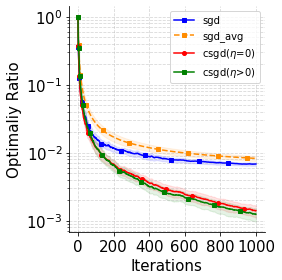

In [126]:
#plt.figure()
tab = np.arange(N+1)
fig,ax = plt.subplots(figsize=(4,4))
plt.plot((mean_sgd-loss_opt)/(mean_sgd[0]-loss_opt),
         color='b',label='sgd',
         linestyle='-',marker='s',markevery=0.1,ms=4)

plt.fill_between(tab,
                 (mean_sgd-loss_opt-std_sgd)/(mean_sgd[0]-loss_opt),
                 (mean_sgd-loss_opt+std_sgd)/(mean_sgd[0]-loss_opt),
                  color='b',alpha=0.1)

plt.plot((mean_sgd_avg-loss_opt)/(mean_sgd_avg[0]-loss_opt),
         color='darkorange',label='sgd_avg',
         linestyle='--',marker='s',markevery=0.1,ms=4)
plt.fill_between(tab,
                 (mean_sgd_avg-loss_opt-std_sgd_avg)/(mean_sgd_avg[0]-loss_opt),
                 (mean_sgd_avg-loss_opt+std_sgd_avg)/(mean_sgd_avg[0]-loss_opt),
                  color='darkorange',alpha=0.1)

plt.plot((mean_equal-loss_opt)/(mean_equal[0]-loss_opt),
         color='red',label=r'csgd($\eta$=0)',
         linestyle='-',marker='o',markevery=0.1,ms=4)
plt.fill_between(tab,
                 (mean_equal-loss_opt-std_equal)/(mean_equal[0]-loss_opt),
                 (mean_equal-loss_opt+std_equal)/(mean_equal[0]-loss_opt),
                  color='red',alpha=0.1)

plt.plot((mean_weighted-loss_opt)/(mean_weighted[0]-loss_opt),
         color='green',label=r'csgd($\eta$>0)',
         linestyle='-',marker='s',markevery=0.1,ms=4)
plt.fill_between(tab,
                 (mean_weighted-loss_opt-std_weighted)/(mean_weighted[0]-loss_opt),
                 (mean_weighted-loss_opt+std_weighted)/(mean_weighted[0]-loss_opt),
                  color='green',alpha=0.1)

plt.yscale('log')
plt.ylabel(r'Optimaliy Ratio',fontsize=15)
plt.xlabel('Iterations',fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(fontsize=15)
plt.legend(loc='upper right',fontsize=10)
plt.grid(linestyle='--',which='both',alpha=0.5)

plt.tight_layout()
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
#plt.savefig('ridge_boston.pdf',bbox_inches='tight',transparent=True,pad_inches=0)
#plt.savefig('ridge_diabetes.pdf',bbox_inches='tight',transparent=True,pad_inches=0)
plt.show()